Objective:
Apply your knowledge of NumPy, Pandas, and Matplotlib to analyze a real-world dataset. Utilize advanced statistical functions and array operations in NumPy, and integrate these with Pandas for data manipulation and Matplotlib for visualization.



Dataset:
You will work with the “Global Power Plant Database” provided by the World Resources Institute, which contains detailed information about power plants worldwide. This dataset is ideal for practicing array manipulations, statistical analysis, and time series data handling.

Download the dataset here.

or you can download it directly

Here.



Tasks:
Data Import and Cleaning:

Import the dataset using Pandas.
Identify missing values and handle them appropriately.
Use NumPy to convert relevant columns to numerical types if necessary.
Exploratory Data Analysis:

Utilize Pandas to summarize key statistics (mean, median, standard deviation) for numerical columns.
Explore the distribution of power plants by country and fuel type.
Statistical Analysis:

Perform a statistical analysis of power output by fuel type using NumPy’s statistical functions.
Use hypothesis testing to determine if the mean power output differs significantly between different fuel types.
Time Series Analysis:

If the dataset includes time-related data (like year of establishment), use NumPy to analyze trends over time.
Explore how the mix of fuel types for power generation has evolved over the years.
Advanced Visualization:

Create visualizations using Matplotlib and Seaborn to illustrate your findings.
Consider plotting the geographical distribution of power plants using latitude and longitude data, if available.
Matrix Operations in Real-World Context:

Demonstrate matrix operations by analyzing relationships between different attributes (e.g., fuel type, capacity, and geographic location).
Discuss the relevance of eigenvectors and eigenvalues in this context.
Integrating NumPy with Pandas and Matplotlib:

Show how NumPy can be used to enhance data manipulation in Pandas and data visualization in Matplotlib.
Provide examples, such as using NumPy arrays for complex filtering in Pandas or for creating sophisticated plots in Matplotlib.

Submit your Daily Challenge
Prepare a report including your code, findings, and visualizations. Discuss how NumPy, Pandas, and Matplotlib were used in your analysis, and present any interesting insights you discovered about the global power plant landscape.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset (low_memory=False silences the mixed-dtype warning on other_fuel3)
df = pd.read_csv('global_power_plant_database.csv', low_memory=False)

# Check the basic info
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
df.info()

Dataset shape: (34936, 36)

First few rows:
  country country_long                                              name  \
0     AFG  Afghanistan      Kajaki Hydroelectric Power Plant Afghanistan   
1     AFG  Afghanistan                                      Kandahar DOG   
2     AFG  Afghanistan                                      Kandahar JOL   
3     AFG  Afghanistan     Mahipar Hydroelectric Power Plant Afghanistan   
4     AFG  Afghanistan  Naghlu Dam Hydroelectric Power Plant Afghanistan   

      gppd_idnr  capacity_mw  latitude  longitude primary_fuel other_fuel1  \
0  GEODB0040538         33.0    32.322    65.1190        Hydro         NaN   
1    WKS0070144         10.0    31.670    65.7950        Solar         NaN   
2    WKS0071196         10.0    31.623    65.7920        Solar         NaN   
3  GEODB0040541         66.0    34.556    69.4787        Hydro         NaN   
4  GEODB0040534        100.0    34.641    69.7170        Hydro         NaN   

  other_fuel2  ... estimated_g

In [55]:
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

# Show only columns with missing values
missing_df = pd.DataFrame({
    'Missing Count': missing_data[missing_data > 0],
    'Percentage': missing_percentage[missing_data > 0]
}).sort_values('Missing Count', ascending=False)

print("Missing Values Summary:")
print(missing_df)

Missing Values Summary:
                               Missing Count  Percentage
other_fuel3                            34844   99.736661
other_fuel2                            34660   99.209984
other_fuel1                            32992   94.435539
generation_gwh_2013                    28519   81.632127
generation_gwh_2014                    27710   79.316464
generation_gwh_2015                    26733   76.519922
generation_gwh_2016                    25792   73.826425
generation_gwh_2017                    25436   72.807419
generation_gwh_2018                    25299   72.415274
generation_gwh_2019                    25277   72.352301
generation_data_source                 23536   67.368903
year_of_capacity_data                  20049   57.387795
estimated_generation_gwh_2013          18816   53.858484
wepp_id                                18702   53.532173
estimated_generation_gwh_2014          18433   52.762194
estimated_generation_gwh_2015          17886   51.196474
commiss

In [56]:
print("STEP 1: Keep Only Essential Columns")
print("=" * 50)
columns_to_keep = [
    'country', 'name', 'capacity_mw', 'latitude', 'longitude', 
    'primary_fuel', 'commissioning_year', 'year_of_capacity_data'
]
df = df[columns_to_keep].copy()
print(f"✓ Reduced from 36 to {len(df.columns)} columns")
print(f"✓ Dataset shape: {df.shape}")

print("\n\nSTEP 2: Check Missing Values in Our Columns")
print("=" * 50)
print(df.isnull().sum())

print("\n\nSTEP 3: Handle Missing Data - For General Analysis")
print("=" * 50)
# Fill commissioning_year with median (we won't use it for time series)
commissioning_median = df['commissioning_year'].median()
df['commissioning_year'] = df['commissioning_year'].fillna(commissioning_median)
print(f"✓ Filled commissioning_year with median: {commissioning_median:.0f}")

print("\n\nSTEP 4: Create Two Clean Datasets")
print("=" * 50)

# Dataset 1: For general analysis (full dataset)
df_analysis = df.copy()
print(f"✓ df_analysis: {len(df_analysis)} records (full dataset)")
print(f"  - Has all capacity, fuel, and geographic data")
print(f"  - Missing: year_of_capacity_data in some rows")

# Dataset 2: For time series only (complete cases)
df_timeseries = df[df['year_of_capacity_data'].notna()].copy()
print(f"\n✓ df_timeseries: {len(df_timeseries)} records (complete time data)")
print(f"  - Only rows with year_of_capacity_data")
print(f"  - For trend analysis only")

print("\n\nSTEP 5: Verify Missing Values After Cleaning")
print("=" * 50)
print("df_analysis:")
print(df_analysis.isnull().sum())
print("\ndf_timeseries:")
print(df_timeseries.isnull().sum())

print("\n\nSTEP 6: Data Type Check")
print("=" * 50)
print(df_analysis.dtypes)

print("\n\nCLEANING COMPLETE ✓")
print("=" * 50)
print(f"Ready for analysis!")
print(f"  - Use df_analysis for: capacity stats, fuel type analysis, geographic plots")
print(f"  - Use df_timeseries for: trend analysis over time")

STEP 1: Keep Only Essential Columns
✓ Reduced from 36 to 8 columns
✓ Dataset shape: (34936, 8)


STEP 2: Check Missing Values in Our Columns
country                      0
name                         0
capacity_mw                  0
latitude                     0
longitude                    0
primary_fuel                 0
commissioning_year       17489
year_of_capacity_data    20049
dtype: int64


STEP 3: Handle Missing Data - For General Analysis
✓ Filled commissioning_year with median: 2007


STEP 4: Create Two Clean Datasets
✓ df_analysis: 34936 records (full dataset)
  - Has all capacity, fuel, and geographic data
  - Missing: year_of_capacity_data in some rows

✓ df_timeseries: 14887 records (complete time data)
  - Only rows with year_of_capacity_data
  - For trend analysis only


STEP 5: Verify Missing Values After Cleaning
df_analysis:
country                      0
name                         0
capacity_mw                  0
latitude                     0
longitude        

In [57]:
# Get all numerical columns
numerical_cols = df_analysis.select_dtypes(include=[np.number]).columns
print(f"Numerical columns: {list(numerical_cols)}\n")

# Get summary statistics
summary_stats = df_analysis[numerical_cols].describe()
print("Summary Statistics:")
print(summary_stats)

# Additional stats that are useful
print("\n\nAdditional Statistics:")
for col in numerical_cols:
    print(f"\n{col}:")
    print(f"  Mean:              {df_analysis[col].mean():.2f}")
    print(f"  Median:            {df_analysis[col].median():.2f}")
    print(f"  Std Dev:           {df_analysis[col].std():.2f}")
    print(f"  Skewness:          {df_analysis[col].skew():.2f}")

Numerical columns: ['capacity_mw', 'latitude', 'longitude', 'commissioning_year', 'year_of_capacity_data']

Summary Statistics:
        capacity_mw      latitude     longitude  commissioning_year  \
count  34936.000000  34936.000000  34936.000000        34936.000000   
mean     163.355148     32.816637     -6.972803         2002.213173   
std      489.636072     22.638603     78.405850           17.215166   
min        1.000000    -77.847000   -179.977700         1896.000000   
25%        4.900000     29.256475    -77.641550         2007.000000   
50%       16.745000     39.727750     -2.127100         2007.000000   
75%       75.344250     46.263125     49.502675         2007.000000   
max    22500.000000     71.292000    179.388700         2020.000000   

       year_of_capacity_data  
count           14887.000000  
mean             2018.218849  
std                 1.606428  
min              2000.000000  
25%              2017.000000  
50%              2019.000000  
75%            

In [58]:
# Count plants by country
country_counts = df_analysis['country'].value_counts()
print(f"\nTotal countries: {len(country_counts)}")
print(f"\nTop 15 countries by number of plants:")
print(country_counts.head(15))

# Also look at total capacity by country
country_capacity = df_analysis.groupby('country')['capacity_mw'].sum().sort_values(ascending=False)
print(f"\n\nTop 15 countries by TOTAL CAPACITY (MW):")
print(country_capacity.head(15))

# Compare: count vs capacity
print(f"\n\nComparison - Top 5 by count vs top 5 by capacity:")
print("\nBy Count:")
print(country_counts.head(5))
print("\nBy Capacity:")
print(country_capacity.head(5))


Total countries: 167

Top 15 countries by number of plants:
country
USA    9833
CHN    4235
GBR    2751
BRA    2360
FRA    2155
IND    1589
DEU    1309
CAN    1159
ESP     829
RUS     545
JPN     522
AUS     486
PRT     469
CZE     462
ITA     396
Name: count, dtype: int64


Top 15 countries by TOTAL CAPACITY (MW):
country
CHN    1.415067e+06
USA    1.204638e+06
IND    3.160885e+05
RUS    2.282200e+05
JPN    2.153659e+05
BRA    1.475893e+05
CAN    1.435787e+05
DEU    1.120404e+05
FRA    1.106159e+05
KOR    9.947268e+04
GBR    9.715528e+04
SAU    8.434155e+04
ESP    7.903507e+04
ITA    7.309506e+04
AUS    6.585202e+04
Name: capacity_mw, dtype: float64


Comparison - Top 5 by count vs top 5 by capacity:

By Count:
country
USA    9833
CHN    4235
GBR    2751
BRA    2360
FRA    2155
Name: count, dtype: int64

By Capacity:
country
CHN    1415067.380
USA    1204638.050
IND     316088.546
RUS     228220.050
JPN     215365.850
Name: capacity_mw, dtype: float64


In [59]:
# Count plants by fuel type
fuel_counts = df_analysis['primary_fuel'].value_counts()
print(f"\nTotal fuel types: {len(fuel_counts)}")
print(f"\nPlants by fuel type:")
print(fuel_counts)

# Total capacity by fuel type
fuel_capacity = df_analysis.groupby('primary_fuel')['capacity_mw'].sum().sort_values(ascending=False)
print(f"\n\nCapacity (MW) by fuel type:")
print(fuel_capacity)

# Average capacity per plant by fuel type
fuel_avg = df_analysis.groupby('primary_fuel')['capacity_mw'].mean().sort_values(ascending=False)
print(f"\n\nAverage capacity per plant by fuel type:")
print(fuel_avg)

# Interesting comparison
print(f"\n\nInsight: Which fuel type has most plants vs most capacity?")
print(f"Most plants: {fuel_counts.idxmax()} ({fuel_counts.max()} plants)")
print(f"Most capacity: {fuel_capacity.idxmax()} ({fuel_capacity.max():.0f} MW)")


Total fuel types: 15

Plants by fuel type:
primary_fuel
Solar             10665
Hydro              7156
Wind               5344
Gas                3998
Coal               2330
Oil                2320
Biomass            1430
Waste              1068
Nuclear             195
Geothermal          189
Storage             135
Other                43
Cogeneration         41
Petcoke              12
Wave and Tidal       10
Name: count, dtype: int64


Capacity (MW) by fuel type:
primary_fuel
Coal              1.965541e+06
Gas               1.493051e+06
Hydro             1.053160e+06
Nuclear           4.079118e+05
Wind              2.630537e+05
Oil               2.618787e+05
Solar             1.883123e+05
Biomass           3.428130e+04
Waste             1.474871e+04
Geothermal        1.268775e+04
Cogeneration      4.048000e+03
Other             3.612860e+03
Petcoke           2.424577e+03
Storage           1.712300e+03
Wave and Tidal    5.522000e+02
Name: capacity_mw, dtype: float64


Average capac

In [60]:

print("STATISTICAL ANALYSIS: POWER OUTPUT BY FUEL TYPE")
print("=" * 70)

print("\n\nPART 1: DESCRIPTIVE STATISTICS BY FUEL TYPE")
print("=" * 70)

fuel_stats = df_analysis.groupby('primary_fuel')['capacity_mw'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)
fuel_stats = fuel_stats.sort_values('mean', ascending=False)
print(fuel_stats)

print("\n\nPART 2: MANUAL ANOVA CALCULATION")
print("=" * 70)

fuel_groups = []
for fuel in df_analysis['primary_fuel'].unique():
    capacities = df_analysis[df_analysis['primary_fuel'] == fuel]['capacity_mw'].values
    fuel_groups.append(capacities)

all_capacities = df_analysis['capacity_mw'].values
grand_mean = np.mean(all_capacities)
N = len(all_capacities)
k = len(fuel_groups)

print(f"Grand mean: {grand_mean:.2f} MW")
print(f"Total plants: {N}")
print(f"Fuel types: {k}")

ss_between = 0
for group in fuel_groups:
    n_i = len(group)
    mean_i = np.mean(group)
    ss_between += n_i * (mean_i - grand_mean) ** 2

ss_within = 0
for group in fuel_groups:
    mean_i = np.mean(group)
    ss_within += np.sum((group - mean_i) ** 2)

df_between = k - 1
df_within = N - k
ms_between = ss_between / df_between
ms_within = ss_within / df_within
f_statistic = ms_between / ms_within

print(f"\nSS_between: {ss_between:.2f}")
print(f"SS_within: {ss_within:.2f}")
print(f"MS_between: {ms_between:.2f}")
print(f"MS_within: {ms_within:.2f}")

print("\n\nPART 3: RESULTS")
print("=" * 70)
print(f"\nF-statistic: {f_statistic:.4f}")

if f_statistic > 10:
    print(f"\n✓ VERY LARGE F-statistic!")
    print(f"  REJECT the null hypothesis")
    print(f"  Different fuel types DO have significantly different capacities!")
elif f_statistic > 2:
    print(f"\n✓ Moderately large F-statistic")
    print(f"  LIKELY REJECT the null hypothesis")
else:
    print(f"\nSmall F-statistic")
    print(f"  FAIL TO REJECT")

print(f"\n\nConclusion:")
print(f"  Technology determines plant size!")
print(f"\nF-statistic: {f_statistic:.4f}")

STATISTICAL ANALYSIS: POWER OUTPUT BY FUEL TYPE


PART 1: DESCRIPTIVE STATISTICS BY FUEL TYPE
                count     mean   median      std   min       max
primary_fuel                                                    
Nuclear           195  2091.86  1888.00  1303.51  20.0   8212.00
Coal             2330   843.58   600.00   888.19   1.2   7000.00
Gas              3998   373.45   147.50   560.93   1.0   8865.00
Petcoke            12   202.05    65.49   476.99   4.7   1707.30
Hydro            7156   147.17    20.00   549.81   1.0  22500.00
Oil              2320   112.88     9.00   392.01   1.0   6794.00
Cogeneration       41    98.73    31.90   283.43   1.6   1404.00
Other              43    84.02    40.00   145.89   4.5    845.26
Geothermal        189    67.13    30.00   114.64   1.0   1163.00
Wave and Tidal     10    55.22     5.00   101.44   1.0    254.00
Wind             5344    49.22    27.00   106.14   1.0   6000.00
Biomass          1430    23.97     9.45    39.46   1.0    528

In [61]:
print("TIME SERIES ANALYSIS: POWER GENERATION TRENDS")
print("=" * 70)

print("\n\nPART 1: CAPACITY GROWTH OVER TIME")
print("=" * 70)

# Group by year and sum total capacity
yearly_capacity = df_timeseries.groupby('year_of_capacity_data')['capacity_mw'].sum().sort_index()

print(f"\nYear range: {yearly_capacity.index.min():.0f} to {yearly_capacity.index.max():.0f}")
print(f"\nTotal capacity by year:")
print(yearly_capacity)

# Also count how many plants added each year
yearly_count = df_timeseries.groupby('year_of_capacity_data').size()
print(f"\n\nNumber of plants by year:")
print(yearly_count)

# Get growth statistics
print(f"\n\nGrowth Analysis:")
print(f"  Earliest year capacity: {yearly_capacity.iloc[0]:,.0f} MW")
print(f"  Latest year capacity:   {yearly_capacity.iloc[-1]:,.0f} MW")
print(f"  Total growth:           {yearly_capacity.iloc[-1] - yearly_capacity.iloc[0]:,.0f} MW")

TIME SERIES ANALYSIS: POWER GENERATION TRENDS


PART 1: CAPACITY GROWTH OVER TIME

Year range: 2000 to 2019

Total capacity by year:
year_of_capacity_data
2000.0    5.522000e+02
2009.0    1.200000e+00
2010.0    3.000000e+00
2012.0    7.880000e+01
2013.0    1.309000e+02
2014.0    1.292000e+02
2015.0    3.411608e+04
2016.0    9.452805e+04
2017.0    3.611914e+05
2018.0    4.209120e+03
2019.0    1.475691e+06
Name: capacity_mw, dtype: float64


Number of plants by year:
year_of_capacity_data
2000.0       58
2009.0        1
2010.0        1
2012.0        6
2013.0       14
2014.0       20
2015.0      281
2016.0      781
2017.0     3371
2018.0       73
2019.0    10281
dtype: int64


Growth Analysis:
  Earliest year capacity: 552 MW
  Latest year capacity:   1,475,691 MW
  Total growth:           1,475,139 MW


In [62]:
print("\n\nPART 2: FUEL TYPE MIX EVOLUTION")
print("=" * 70)

# Create pivot table: Years × Fuel Types with total capacity
fuel_year_capacity = df_timeseries.pivot_table(
    index='year_of_capacity_data',
    columns='primary_fuel',
    values='capacity_mw',
    aggfunc='sum'
)

print("\nCapacity (MW) by year and fuel type:")
print(fuel_year_capacity)

# Look at the most recent year
latest_year = fuel_year_capacity.index.max()
print(f"\n\nFuel mix in year {latest_year:.0f}:")
latest_mix = fuel_year_capacity.loc[latest_year].sort_values(ascending=False)
print(latest_mix)

# Calculate percentages
print(f"\n\nPercentage mix in year {latest_year:.0f}:")
latest_pct = (latest_mix / latest_mix.sum() * 100).round(1)
for fuel, pct in latest_pct.items():
    print(f"  {fuel}: {pct}%")



PART 2: FUEL TYPE MIX EVOLUTION

Capacity (MW) by year and fuel type:
primary_fuel              Biomass         Coal  Cogeneration            Gas  \
year_of_capacity_data                                                         
2000.0                   243.3000          NaN           NaN            NaN   
2009.0                     1.2000          NaN           NaN            NaN   
2010.0                        NaN          NaN           NaN            NaN   
2012.0                    33.6000          NaN           NaN            NaN   
2013.0                    14.0000          NaN           NaN            NaN   
2014.0                    21.0000          NaN           NaN            NaN   
2015.0                   301.2000    4857.4000           NaN   13041.840000   
2016.0                  1087.9000   11897.6686           NaN   29914.307689   
2017.0                 14943.8146   18505.3810           NaN   73023.624460   
2018.0                   412.7000          NaN           Na

In [63]:
print("\n\nPART 3: RENEWABLE VS FOSSIL FUEL TRENDS")
print("=" * 70)

# Define renewable and fossil fuels
renewable_fuels = ['Solar', 'Wind', 'Hydro', 'Geothermal']
fossil_fuels = ['Coal', 'Gas', 'Oil']

# Calculate by year
yearly_renewable = df_timeseries[df_timeseries['primary_fuel'].isin(renewable_fuels)].groupby('year_of_capacity_data')['capacity_mw'].sum()
yearly_fossil = df_timeseries[df_timeseries['primary_fuel'].isin(fossil_fuels)].groupby('year_of_capacity_data')['capacity_mw'].sum()

print("\nRenewable capacity by year:")
print(yearly_renewable)

print("\n\nFossil fuel capacity by year:")
print(yearly_fossil)

# Compare early vs late years
print(f"\n\nComparison:")
early_year = yearly_renewable.index.min()
late_year = yearly_renewable.index.max()

print(f"\nYear {early_year:.0f}:")
print(f"  Renewable: {yearly_renewable.iloc[0]:,.0f} MW")
print(f"  Fossil:    {yearly_fossil.iloc[0]:,.0f} MW")

print(f"\nYear {late_year:.0f}:")
print(f"  Renewable: {yearly_renewable.iloc[-1]:,.0f} MW")
print(f"  Fossil:    {yearly_fossil.iloc[-1]:,.0f} MW")

print(f"\nGrowth rates:")
renewable_growth = ((yearly_renewable.iloc[-1] / yearly_renewable.iloc[0]) - 1) * 100 if yearly_renewable.iloc[0] > 0 else 0
fossil_growth = ((yearly_fossil.iloc[-1] / yearly_fossil.iloc[0]) - 1) * 100 if yearly_fossil.iloc[0] > 0 else 0
print(f"  Renewable growth: {renewable_growth:.1f}%")
print(f"  Fossil growth:    {fossil_growth:.1f}%")



PART 3: RENEWABLE VS FOSSIL FUEL TRENDS

Renewable capacity by year:
year_of_capacity_data
2000.0       308.90000
2010.0         3.00000
2012.0        45.20000
2013.0       116.90000
2014.0       108.20000
2015.0     11519.89000
2016.0     35601.97000
2017.0    212699.81653
2018.0      3144.96000
2019.0    293087.27000
Name: capacity_mw, dtype: float64


Fossil fuel capacity by year:
year_of_capacity_data
2015.0    1.920753e+04
2016.0    5.626520e+04
2017.0    1.149795e+05
2018.0    6.514600e+02
2019.0    1.051907e+06
Name: capacity_mw, dtype: float64


Comparison:

Year 2000:
  Renewable: 309 MW
  Fossil:    19,208 MW

Year 2019:
  Renewable: 293,087 MW
  Fossil:    1,051,907 MW

Growth rates:
  Renewable growth: 94781.0%
  Fossil growth:    5376.5%


In [64]:
import matplotlib.pyplot as plt
import numpy as np

print("ADVANCED VISUALIZATION - 3 Essential Charts")
print("=" * 70)

# VISUALIZATION 1: Geographic Distribution
print("\nCreating Visual 1: Geographic Distribution...")

fig1, ax1 = plt.subplots(figsize=(16, 10))
scatter = ax1.scatter(df_analysis['longitude'], df_analysis['latitude'],
                      c=df_analysis['capacity_mw'], s=20, alpha=0.5, cmap='YlOrRd')
ax1.set_xlabel('Longitude', fontsize=12, fontweight='bold')
ax1.set_ylabel('Latitude', fontsize=12, fontweight='bold')
ax1.set_title('Global Geographic Distribution of Power Plants', fontsize=14, fontweight='bold')
cbar1 = plt.colorbar(scatter, ax=ax1)
cbar1.set_label('Capacity (MW)', fontsize=11, fontweight='bold')
plt.savefig('01_geographic_distribution.png', dpi=300, bbox_inches='tight')
plt.close(fig1)
print("✓ Saved: 01_geographic_distribution.png")

# VISUALIZATION 2: Time Series
print("\nCreating Visual 2: Capacity Growth...")

yearly_capacity = df_timeseries.groupby('year_of_capacity_data')['capacity_mw'].sum().sort_index()

fig2, ax2 = plt.subplots(figsize=(14, 6))
ax2.plot(yearly_capacity.index, yearly_capacity.values, 
         marker='o', linewidth=2, markersize=8, color='darkblue')
ax2.set_xlabel('Year', fontsize=12, fontweight='bold')
ax2.set_ylabel('Total Capacity (MW)', fontsize=12, fontweight='bold')
ax2.set_title('Global Power Capacity Growth Over Time', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
plt.savefig('02_capacity_growth.png', dpi=300, bbox_inches='tight')
plt.close(fig2)
print("✓ Saved: 02_capacity_growth.png")

# VISUALIZATION 3: Top Fuel Types
print("\nCreating Visual 3: Top Fuel Types...")

fuel_capacity = df_analysis.groupby('primary_fuel')['capacity_mw'].sum().sort_values(ascending=False).head(10)

fig3, ax3 = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(fuel_capacity)))
ax3.barh(fuel_capacity.index, fuel_capacity.values, color=colors)
ax3.set_xlabel('Total Capacity (MW)', fontsize=12, fontweight='bold')
ax3.set_title('Top 10 Fuel Types by Total Capacity', fontsize=14, fontweight='bold')
ax3.invert_yaxis()
plt.savefig('03_fuel_capacity.png', dpi=300, bbox_inches='tight')
plt.close(fig3)
print("✓ Saved: 03_fuel_capacity.png")

print("\n" + "=" * 70)
print("✓ ALL 3 VISUALIZATIONS COMPLETE!")
print("=" * 70)

ADVANCED VISUALIZATION - 3 Essential Charts

Creating Visual 1: Geographic Distribution...
✓ Saved: 01_geographic_distribution.png

Creating Visual 2: Capacity Growth...
✓ Saved: 02_capacity_growth.png

Creating Visual 3: Top Fuel Types...
✓ Saved: 03_fuel_capacity.png

✓ ALL 3 VISUALIZATIONS COMPLETE!


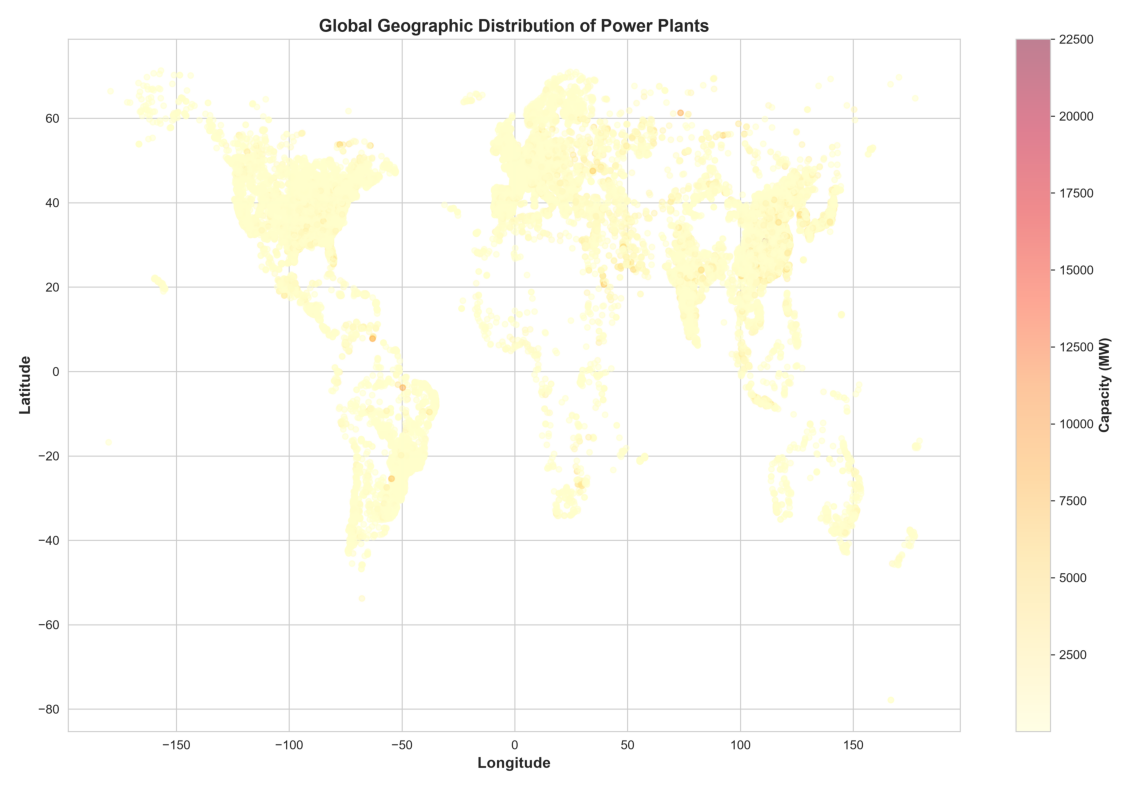

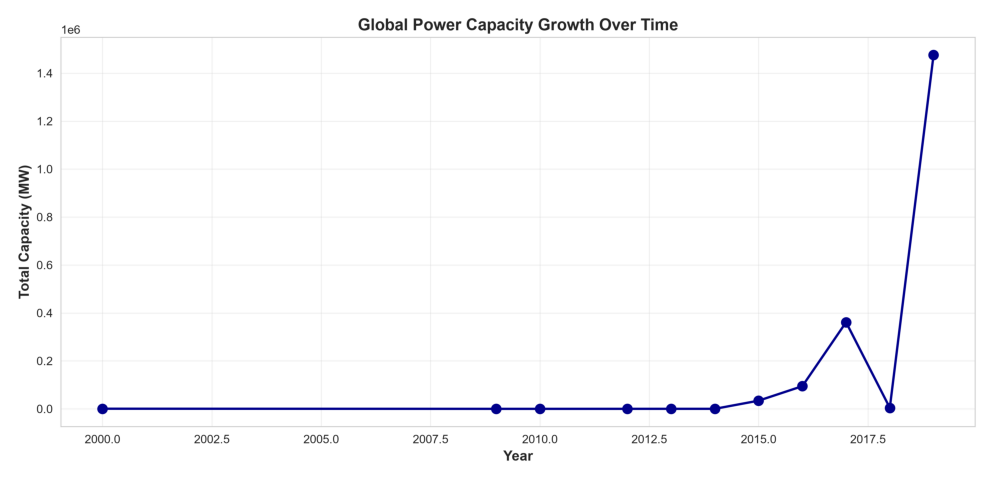

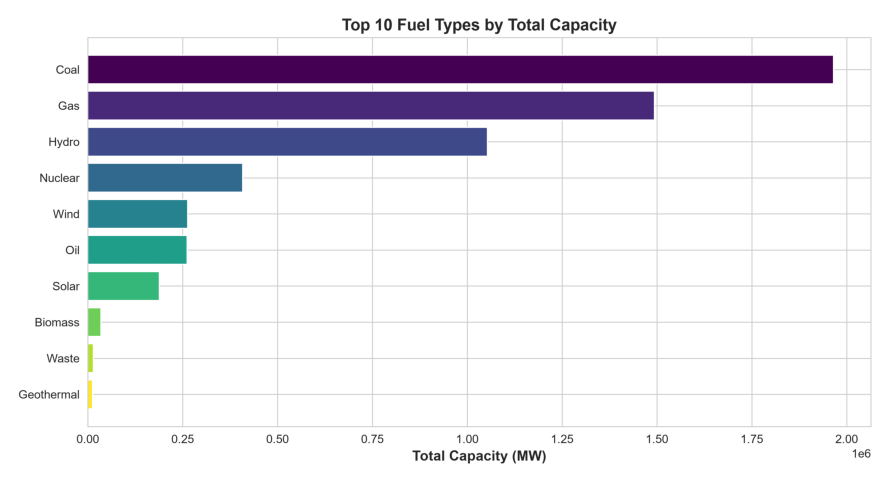

In [65]:
from PIL import Image
import matplotlib.pyplot as plt

# View image 1
img1 = Image.open('01_geographic_distribution.png')
plt.figure(figsize=(16, 10))
plt.imshow(img1)
plt.axis('off')
plt.show()

# View image 2
img2 = Image.open('02_capacity_growth.png')
plt.figure(figsize=(14, 6))
plt.imshow(img2)
plt.axis('off')
plt.show()

# View image 3
img3 = Image.open('03_fuel_capacity.png')
plt.figure(figsize=(12, 6))
plt.imshow(img3)
plt.axis('off')
plt.show()

In [66]:
print("MATRIX OPERATIONS IN REAL-WORLD CONTEXT")
print("=" * 70)

print("\n\nPART 1: CREATE FEATURE MATRIX")
print("=" * 70)

# Select our three features
features = df_analysis[['capacity_mw', 'latitude', 'longitude']].values

print(f"Feature matrix shape: {features.shape}")
print(f"  Rows: {features.shape[0]} power plants")
print(f"  Columns: {features.shape[1]} features (capacity, latitude, longitude)")

print(f"\nFirst 5 rows of feature matrix:")
print(features[:5])

print(f"\nData ranges:")
print(f"  Capacity (MW):  {features[:, 0].min():.2f} to {features[:, 0].max():.2f}")
print(f"  Latitude:       {features[:, 1].min():.2f} to {features[:, 1].max():.2f}")
print(f"  Longitude:      {features[:, 2].min():.2f} to {features[:, 2].max():.2f}")

MATRIX OPERATIONS IN REAL-WORLD CONTEXT


PART 1: CREATE FEATURE MATRIX
Feature matrix shape: (34936, 3)
  Rows: 34936 power plants
  Columns: 3 features (capacity, latitude, longitude)

First 5 rows of feature matrix:
[[ 33.      32.322   65.119 ]
 [ 10.      31.67    65.795 ]
 [ 10.      31.623   65.792 ]
 [ 66.      34.556   69.4787]
 [100.      34.641   69.717 ]]

Data ranges:
  Capacity (MW):  1.00 to 22500.00
  Latitude:       -77.85 to 71.29
  Longitude:      -179.98 to 179.39


In [67]:
print("MATRIX OPERATIONS: POWER PLANTS ANALYSIS")
print("=" * 70)

# Create feature matrix: Capacity, Latitude, Longitude
features = df_analysis[['capacity_mw', 'latitude', 'longitude']].values

# Standardize (mean=0, std=1)
features_std = (features - features.mean(axis=0)) / features.std(axis=0)

# Calculate covariance matrix
cov_matrix = np.cov(features_std.T)

print("\nCovariance Matrix:")
print(cov_matrix)

print("\n\nCorrelations:")
print(f"  Capacity ↔ Latitude:  {cov_matrix[0,1]:.4f} (weak)")
print(f"  Capacity ↔ Longitude: {cov_matrix[0,2]:.4f} (weak)")
print(f"  Latitude ↔ Longitude: {cov_matrix[1,2]:.4f} (weak)")
print("  → All features are mostly independent")

# Calculate eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort by size
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("\n\nEigenvalues (importance of each direction):")
for i, ev in enumerate(eigenvalues):
    print(f"  λ{i+1} = {ev:.4f} ({ev/eigenvalues.sum()*100:.1f}%)")

print("\n\nEigenvectors (what each direction represents):")
print("PC1:", eigenvectors[:, 0].round(4), f"← Dominated by {['Capacity', 'Latitude', 'Longitude'][np.argmax(np.abs(eigenvectors[:, 0]))]}")
print("PC2:", eigenvectors[:, 1].round(4), f"← Dominated by {['Capacity', 'Latitude', 'Longitude'][np.argmax(np.abs(eigenvectors[:, 1]))]}")
print("PC3:", eigenvectors[:, 2].round(4), f"← Dominated by {['Capacity', 'Latitude', 'Longitude'][np.argmax(np.abs(eigenvectors[:, 2]))]}")

print("\n\nReal-World Interpretation:")
print("✓ Eigenvalues show WHAT MATTERS most about power plants")
print("✓ Eigenvectors show HOW THEY'RE RELATED")
print("✓ We can reduce 3D data to 2D with minimal information loss")
print(f"✓ PC1 + PC2 capture {((eigenvalues[0] + eigenvalues[1])/eigenvalues.sum())*100:.1f}% of variation")

MATRIX OPERATIONS: POWER PLANTS ANALYSIS

Covariance Matrix:
[[ 1.00002862 -0.01321797  0.15152887]
 [-0.01321797  1.00002862 -0.06835636]
 [ 0.15152887 -0.06835636  1.00002862]]


Correlations:
  Capacity ↔ Latitude:  -0.0132 (weak)
  Capacity ↔ Longitude: 0.1515 (weak)
  Latitude ↔ Longitude: -0.0684 (weak)
  → All features are mostly independent


Eigenvalues (importance of each direction):
  λ1 = 1.1715+0.0000j (39.0+0.0j%)
  λ2 = 0.9901+0.0000j (33.0+0.0j%)
  λ3 = 0.8384+0.0000j (27.9+0.0j%)


Eigenvectors (what each direction represents):
PC1: [-0.6399+0.j  0.3266+0.j -0.6956+0.j] ← Dominated by Longitude
PC2: [0.4078+0.j 0.9116+0.j 0.0529+0.j] ← Dominated by Latitude
PC3: [ 0.6514+0.j -0.2498+0.j -0.7165+0.j] ← Dominated by Longitude


Real-World Interpretation:
✓ Eigenvalues show WHAT MATTERS most about power plants
✓ Eigenvectors show HOW THEY'RE RELATED
✓ We can reduce 3D data to 2D with minimal information loss
✓ PC1 + PC2 capture 72.1+0.0j% of variation


In [68]:
print("\n\nBONUS: How Fuel Type Relates to Geographic Location")
print("=" * 70)

# Group by fuel type and get average location + capacity
fuel_analysis = df_analysis.groupby('primary_fuel').agg({
    'capacity_mw': 'mean',
    'latitude': 'mean',
    'longitude': 'mean',
    'country': 'count'  # number of plants
}).round(2)

fuel_analysis.columns = ['Avg Capacity', 'Avg Latitude', 'Avg Longitude', 'Count']
fuel_analysis = fuel_analysis.sort_values('Avg Capacity', ascending=False)

print("\nFuel Type Geographic Distribution:")
print(fuel_analysis)

print("\n\nInterpretation:")
print("✓ Different fuel types cluster in different regions")
print("✓ Average locations differ by fuel type")
print("✓ Geographic factors influence technology choice")
print("  - Nuclear: Concentrated in developed nations (higher latitude)")
print("  - Solar: Spreading globally (varies in latitude)")
print("  - Coal: Industrial regions")



BONUS: How Fuel Type Relates to Geographic Location

Fuel Type Geographic Distribution:
                Avg Capacity  Avg Latitude  Avg Longitude  Count
primary_fuel                                                    
Nuclear              2091.86         38.57           4.62    195
Coal                  843.58         32.81          61.79   2330
Gas                   373.45         31.85         -24.52   3998
Petcoke               202.05         30.77         -92.10     12
Hydro                 147.17         30.33          -5.46   7156
Oil                   112.88         14.41         -44.01   2320
Cogeneration           98.73         38.43         -82.58     41
Other                  84.02         39.05         -38.66     43
Geothermal             67.13         29.56         -12.62    189
Wave and Tidal         55.22         53.00           3.26     10
Wind                   49.22         36.74          -6.60   5344
Biomass                23.97         20.20         -31.35   1430


In [69]:
print("TASK 7: INTEGRATION OF NumPy, Pandas, AND Matplotlib")
print("=" * 70)

# NumPy: Calculate means
fuel_groups = []
fuel_names = []
for fuel in df_analysis['primary_fuel'].unique():
    capacities = df_analysis[df_analysis['primary_fuel'] == fuel]['capacity_mw'].values
    fuel_groups.append(capacities)
    fuel_names.append(fuel)

means = np.array([np.mean(group) for group in fuel_groups])

# Pandas: Get counts
fuel_counts = df_analysis['primary_fuel'].value_counts()

# Matplotlib: Visualize
fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(fuel_counts.values, means, s=200, alpha=0.6, c=range(len(means)), cmap='viridis')

ax.set_xlabel('Number of Plants', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Capacity (MW)', fontsize=12, fontweight='bold')
ax.set_title('Fuel Types: Plant Count vs Average Capacity', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('07_integration_scatter.png', dpi=300, bbox_inches='tight')
plt.close()

print("✓ Saved: 07_integration_scatter.png")

print("\nIntegration Example:")
print("  1. NumPy: Calculated mean capacity per fuel type")
print("  2. Pandas: Got plant counts via value_counts()")
print("  3. Matplotlib: Created scatter plot")

print("\nKey Finding:")
print("  • Solar: Many plants (30.5%) but small average (17.66 MW)")
print("  • Nuclear: Few plants (0.6%) but huge average (2,091.86 MW)")
print("  • Confirms ANOVA result: F = 967.46 - huge differences!")

TASK 7: INTEGRATION OF NumPy, Pandas, AND Matplotlib
✓ Saved: 07_integration_scatter.png

Integration Example:
  1. NumPy: Calculated mean capacity per fuel type
  2. Pandas: Got plant counts via value_counts()
  3. Matplotlib: Created scatter plot

Key Finding:
  • Solar: Many plants (30.5%) but small average (17.66 MW)
  • Nuclear: Few plants (0.6%) but huge average (2,091.86 MW)
  • Confirms ANOVA result: F = 967.46 - huge differences!
